In [5]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from Model import *
from Utils import *
from Metrics import *
from LossUtils import *
from Preprocess import *
from collections import Counter
from matplotlib.ticker import FormatStrFormatter

plt.rcParams['figure.figsize'] = (6, 6)
warnings.filterwarnings('ignore', category=UserWarning)

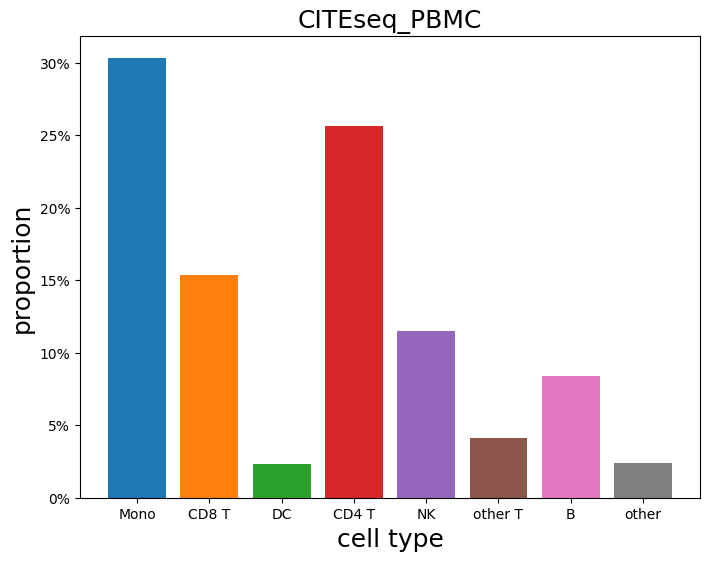

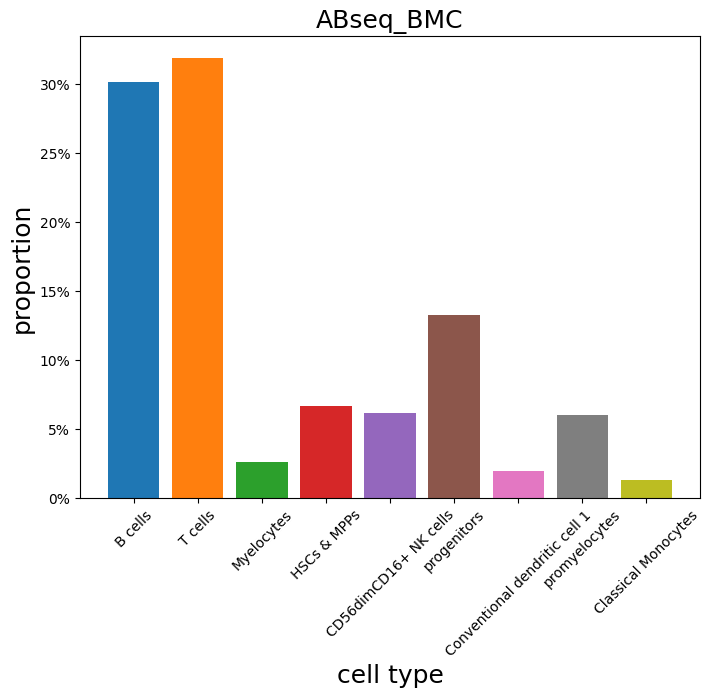

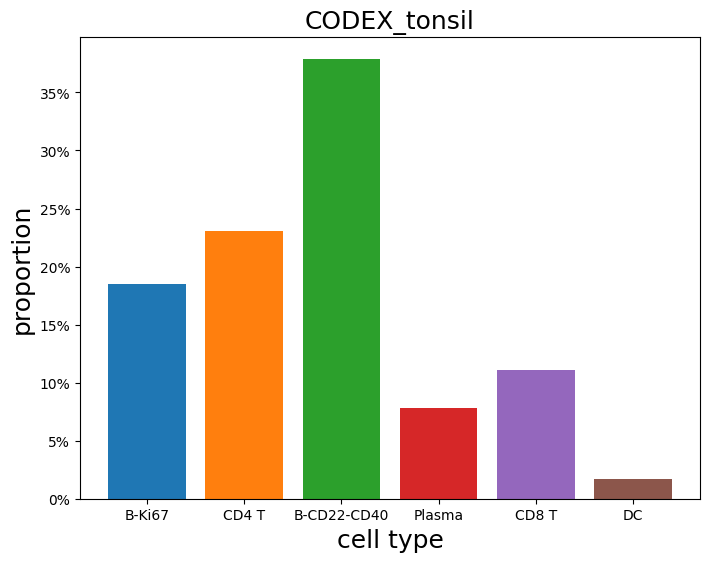

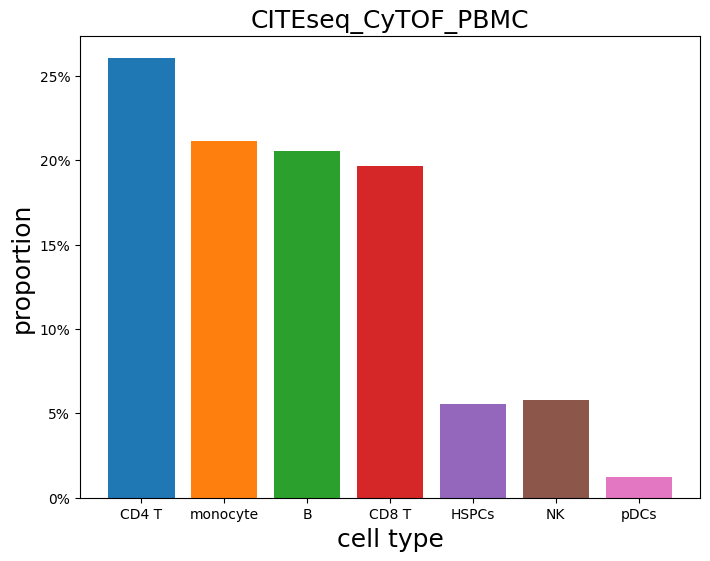

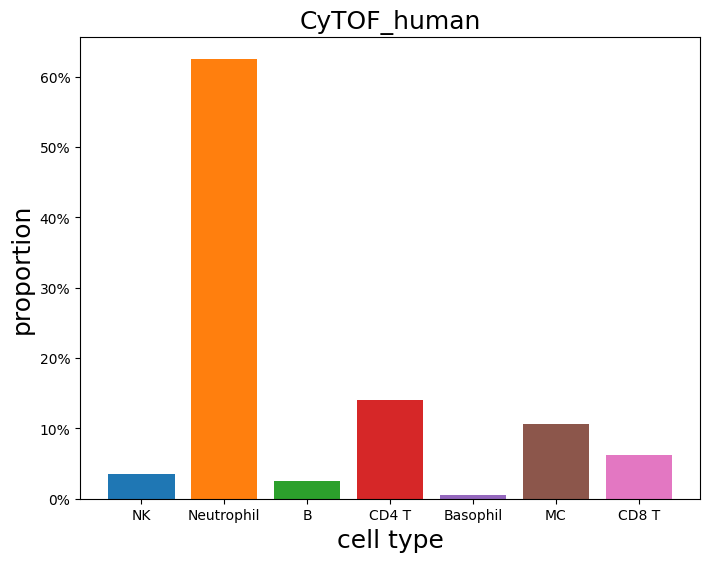

In [6]:
dataset_names = ['CITEseq_PBMC', 'ABseq_BMC', 'CODEX_tonsil', 'CITEseq_CyTOF_PBMC', 'CyTOF_human']

for dataset_name in dataset_names:
    shared_adata_1, shared_adata_2, all_adata_1, all_adata_2 = readDataset(dataset_name)
    
    labels_1, labels_2 = getLabels(
        dataset_name=dataset_name,
        adata_1=shared_adata_1,
        adata_2=shared_adata_2
    )
    
    if dataset_name in ['CITEseq_PBMC', 'ABseq_BMC']:
        names = labels_1
    else:
        names = labels_1 + labels_2
        
    name_counts = Counter(names)

    names = list(name_counts.keys())
    counts = list(name_counts.values())
    total_count = sum(counts)
    frequencies = [count / total_count * 100 for count in counts]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    plt.figure(figsize=(8, 6))
    plt.bar(names, frequencies, color=colors[:len(names)])
    
    if dataset_name == 'ABseq_BMC':
        plt.xticks(fontsize=10, rotation=45)
    else:
        plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.0f%%'))

    plt.title(dataset_name, fontsize=18)
    plt.xlabel('cell type', fontsize=18)
    plt.ylabel('proportion', fontsize=18)

In [7]:
dataset_names = ['CITEseq_PBMC', 'ABseq_BMC', 'CODEX_tonsil', 'CITEseq_CyTOF_PBMC', 'CyTOF_human']

for dataset_name in dataset_names:
    shared_adata_1, shared_adata_2, all_adata_1, all_adata_2 = readDataset(dataset_name)
    
    labels_1, labels_2 = getLabels(
        dataset_name=dataset_name,
        adata_1=shared_adata_1,
        adata_2=shared_adata_2
    )
    
    if dataset_name in ['CITEseq_PBMC', 'ABseq_BMC']:
        names = labels_1
    else:
        names = labels_1 + labels_2
        
    name_counts = Counter(names)

    names = list(name_counts.keys())
    counts = list(name_counts.values())
    total_count = sum(counts)
    frequencies = [count / total_count for count in counts]
    std_dev = np.std(frequencies)
    
    if dataset_name in ['CITEseq_PBMC', 'ABseq_BMC', 'CODEX_tonsil']:
        print(dataset_name, '\tweak\t', std_dev)
    else:
        print(dataset_name, '\tstrong\t', std_dev)

CITEseq_PBMC 	weak	 0.0994937812126969
ABseq_BMC 	weak	 0.11164753512176356
CODEX_tonsil 	weak	 0.11764797744637272
CITEseq_CyTOF_PBMC 	strong	 0.09052057551649091
CyTOF_human 	strong	 0.20186702028204365
